<a href="https://colab.research.google.com/github/alonsap/aaa/blob/main/White%20Wine%20Quality%20Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"alonsapir","key":"b2d8245b1eac7641a7d83f5b7a70eb1e"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d piyushagni5/white-wine-quality
!unzip -o white-wine-quality.zip

Dataset URL: https://www.kaggle.com/datasets/piyushagni5/white-wine-quality
License(s): DbCL-1.0
white-wine-quality.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  white-wine-quality.zip
  inflating: winequality-white.csv   
  inflating: winequality.names       


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alonsap/aaa/blob/main/final_work.ipynb)

<div dir="rtl" style="text-align: center;">

# **המכון הטכנולוגי חולון (HIT)**
## הנדסת חשמל ואלקטרוניקה

<br>

# **Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection**

<hr style="width: 50%; margin: auto;">

<br>

**שם הסטודנט:** אלון ספיר
**מספר זהות:** 214316762

**קורס:** מדע נתונים
**מרצה:** ד"ר אורי איתי
**מתרגלת:** גבריאלה וגנר



</div>

## **1. Dataset Description**

* **Where the dataset comes from:** The dataset is sourced from Kaggle, originating from the UCI Machine Learning Repository. It contains physicochemical tests of samples of white variants of the Portuguese "Vinho Verde" wine.
* **Why it was collected:** It was collected to create computational models capable of evaluating wine quality based on objective chemical tests. This helps the wine industry certify quality and improve production without relying entirely on subjective human sensory evaluations.
* **Who collected it:** The data was collected from May 2004 to February 2007 by Paulo Cortez (University of Minho), A. Cerdeira, F. Almeida, T. Matos, and J. Reis from the Viticulture Commission of the Vinho Verde Region, Portugal.
* **What each feature represents:**
    1. **fixed acidity:** Most acids involved with wine that do not evaporate readily.
    2. **volatile acidity:** The amount of acetic acid in wine, which at high levels can lead to an unpleasant vinegar taste.
    3. **citric acid:** Found in small quantities, it can add 'freshness' and flavor to wines.
    4. **residual sugar:** The amount of sugar remaining after fermentation stops.
    5. **chlorides:** The amount of salt in the wine.
    6. **free sulfur dioxide:** Exists in equilibrium between molecular SO2 and bisulfite ion; prevents microbial growth and oxidation of wine.
    7. **total sulfur dioxide:** The amount of free and bound forms of SO2.
    8. **density:** The density of the wine, which is dependent on the percent alcohol and sugar content.
    9. **pH:** Describes how acidic or basic the wine is on a scale from 0 (very acidic) to 14 (very basic).
    10. **sulphates:** A wine additive which can contribute to sulfur dioxide gas (SO2) levels, acting as an antimicrobial and antioxidant.
    11. **alcohol:** The percent alcohol content of the wine.
* **Possible limitations or biases in the data:**
    * **Geographical Bias:** The dataset exclusively contains wines from a single specific region in Portugal (Vinho Verde). The chemical profiles might not generalize to wines produced in other global regions, climates, or soil types.
    * **Measurement Noise:** Physicochemical tests have inherent sensor and measurement errors, which might introduce slight noise into the continuous variables and affect distance-based algorithms.

In [4]:
import pandas as pd

# הקובץ המקורי של מאגר היין מופרד לרוב על ידי נקודה-פסיק (;), לכן נוסיף sep=';'
df = pd.read_csv('winequality-white.csv', sep=';')

# לפעמים בקאגל הפורמט מתעדכן לפסיק רגיל, נוודא שהקריאה עבדה טוב:
if len(df.columns) <= 1:
    df = pd.read_csv('winequality-white.csv')

if 'quality' in df.columns:
    df = df.drop('quality', axis=1)

# הדפסת מבנה הנתונים ווידוא
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} features")
display(df.head())

Dataset Shape: 4898 rows, 11 features


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9


# **2. Exploratory Data Analysis (EDA)**

## **2.1 Structural Analysis**
**Overview:**
In this section, we examine the fundamental structure of the dataset. This includes verifying the number of rows and columns, checking for missing values, understanding the data types, and calculating basic statistical summaries. Finally, we generate a correlation matrix to identify linear relationships between the physicochemical properties of the wine.

--- Data Types and Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
dtypes: float64(11)
memory usage: 421.1 KB

--- Missing Values Count ---
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides      

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000


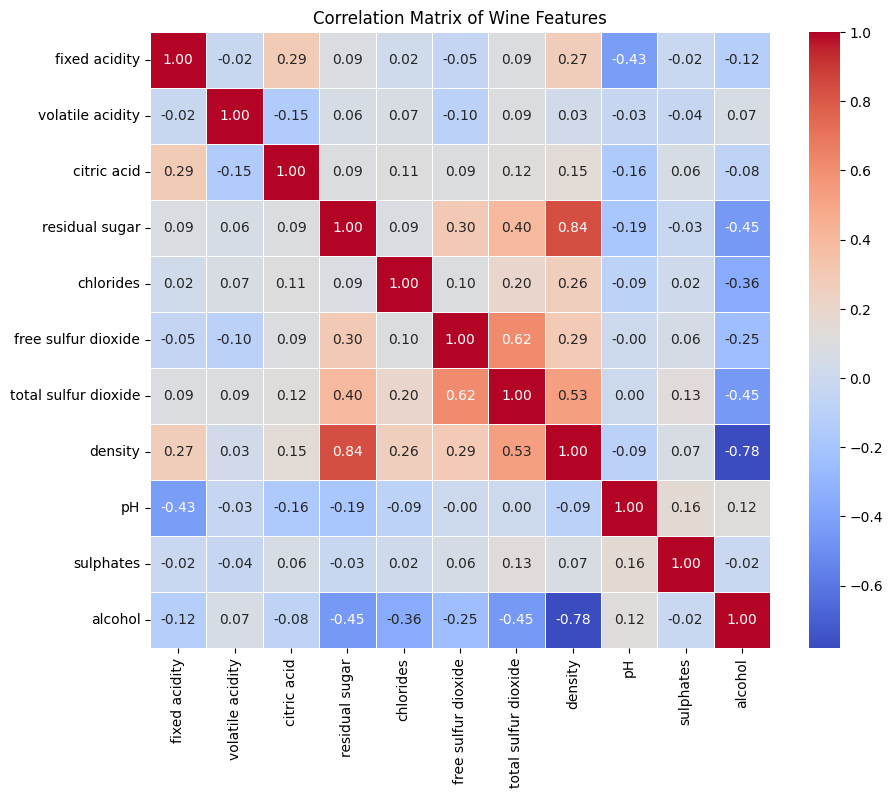

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Data Types and Missing Values ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

print("\n--- Statistical Summary ---")
display(df.describe())

# Correlation Matrix
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Wine Features")
plt.show()

## **2.2 Distribution Analysis**
**Overview:**
Here, we analyze the distribution of each feature. For every numerical variable, we plot a histogram (to view the shape of the distribution) and a boxplot (to identify spread and potential outliers). We also calculate the skewness (measure of asymmetry) and kurtosis (measure of 'tailedness') for each feature to quantify their deviation from a normal distribution.

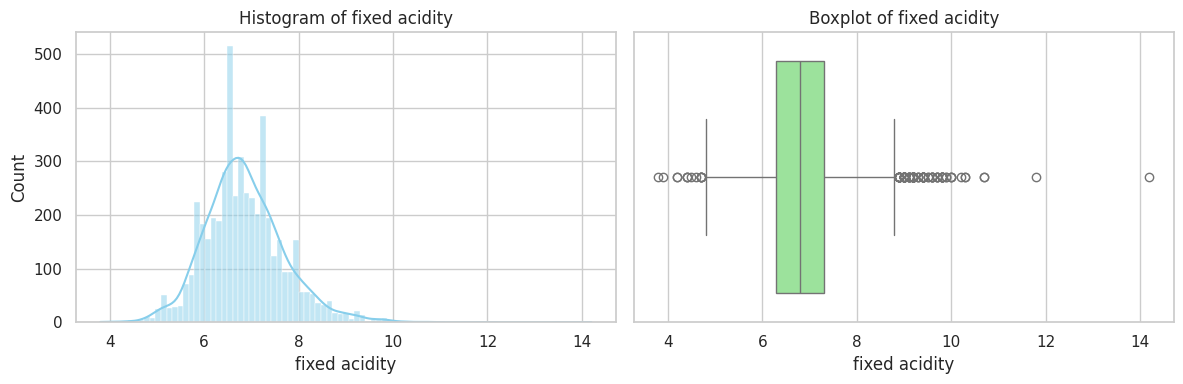

Feature: fixed acidity | Skewness: 0.65 | Kurtosis: 2.17

------------------------------------------------------------


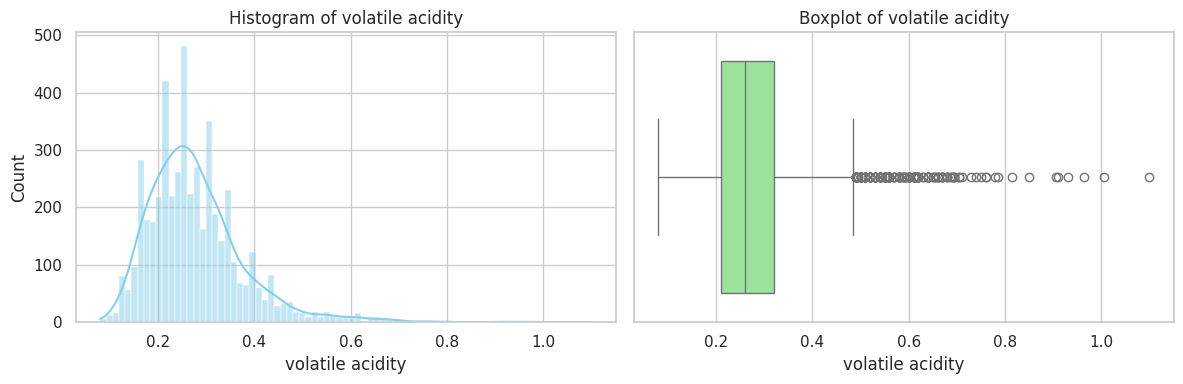

Feature: volatile acidity | Skewness: 1.58 | Kurtosis: 5.09

------------------------------------------------------------


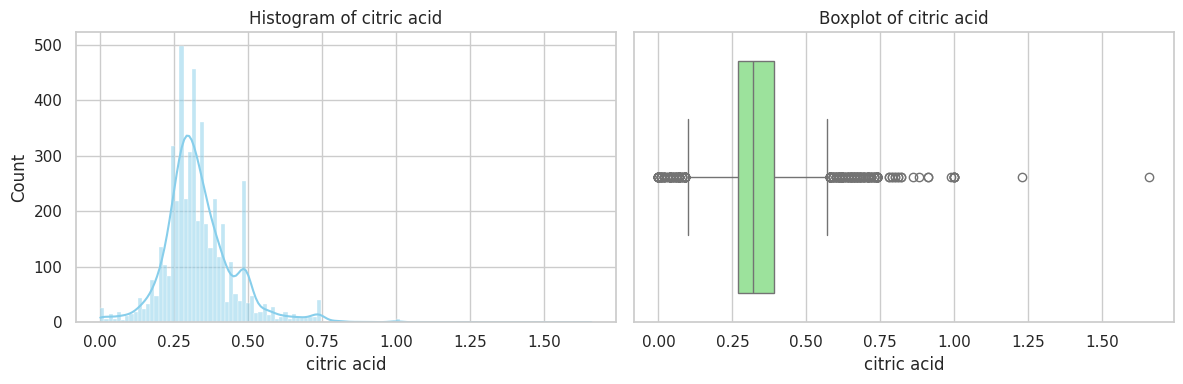

Feature: citric acid | Skewness: 1.28 | Kurtosis: 6.17

------------------------------------------------------------


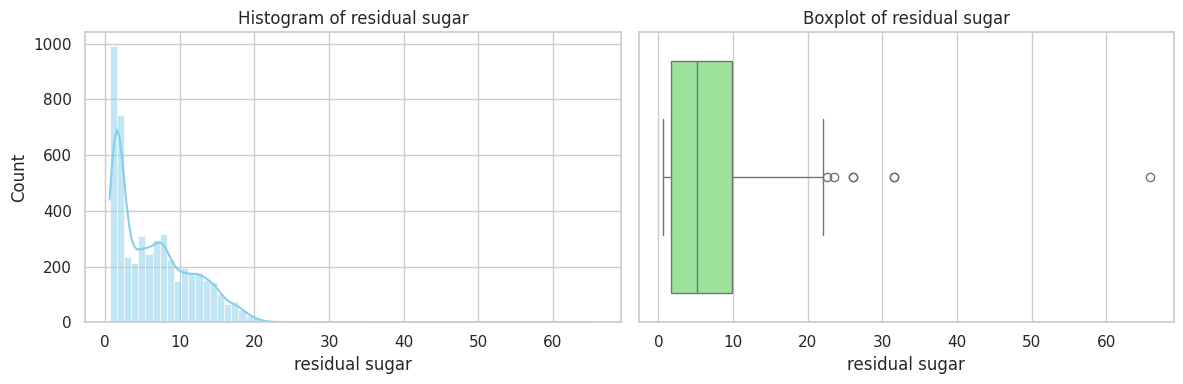

Feature: residual sugar | Skewness: 1.08 | Kurtosis: 3.47

------------------------------------------------------------


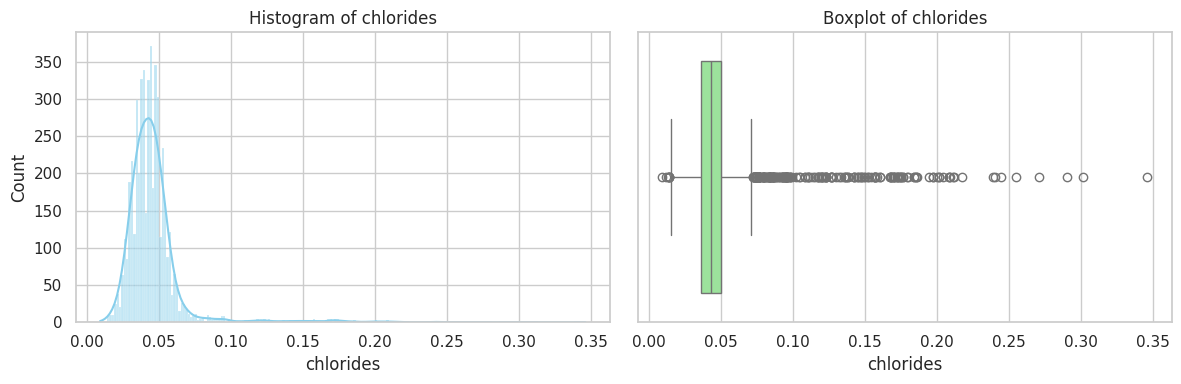

Feature: chlorides | Skewness: 5.02 | Kurtosis: 37.56

------------------------------------------------------------


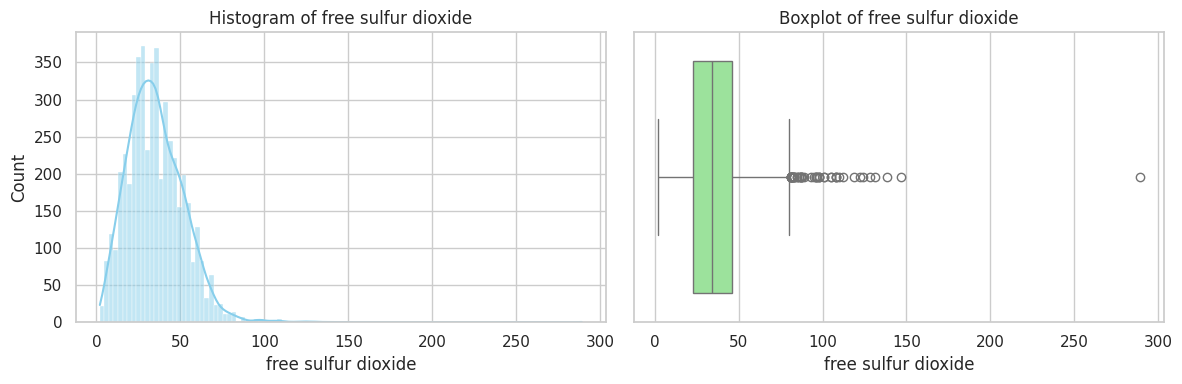

Feature: free sulfur dioxide | Skewness: 1.41 | Kurtosis: 11.47

------------------------------------------------------------


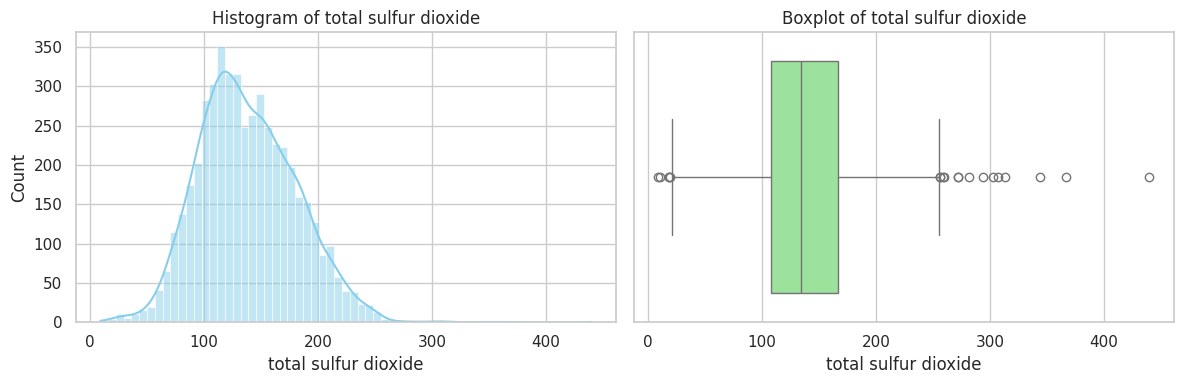

Feature: total sulfur dioxide | Skewness: 0.39 | Kurtosis: 0.57

------------------------------------------------------------


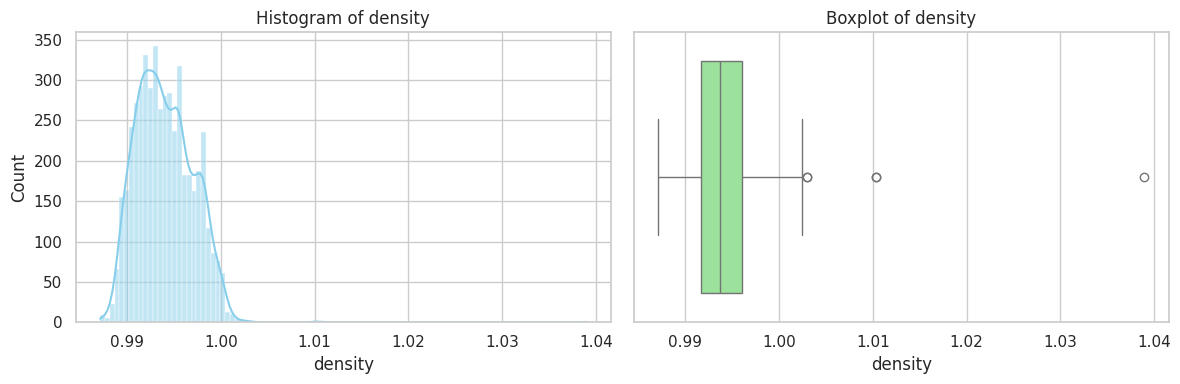

Feature: density | Skewness: 0.98 | Kurtosis: 9.79

------------------------------------------------------------


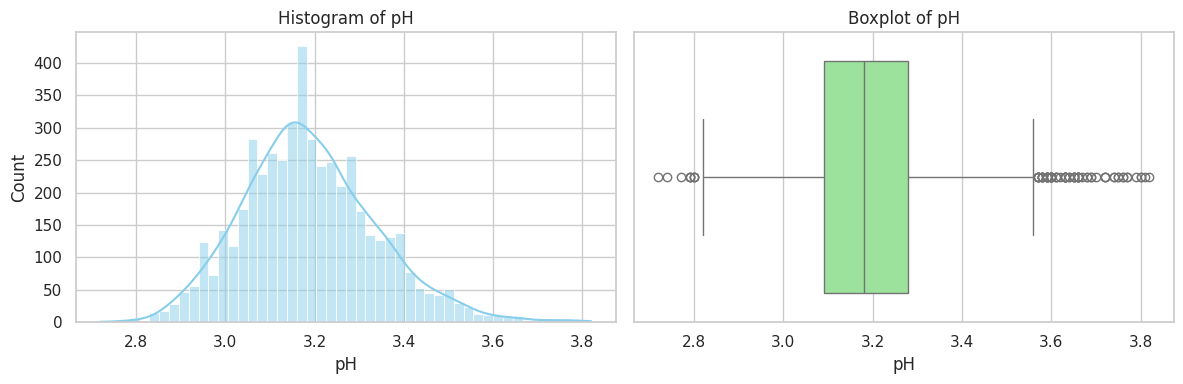

Feature: pH | Skewness: 0.46 | Kurtosis: 0.53

------------------------------------------------------------


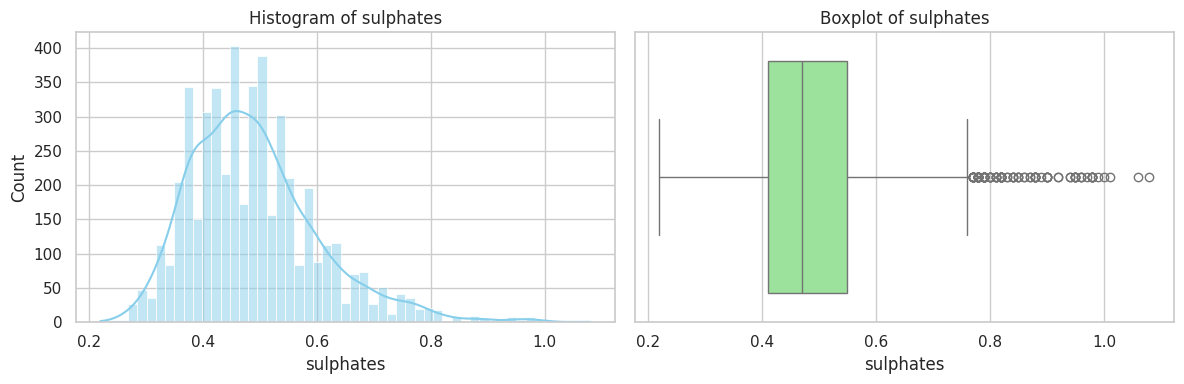

Feature: sulphates | Skewness: 0.98 | Kurtosis: 1.59

------------------------------------------------------------


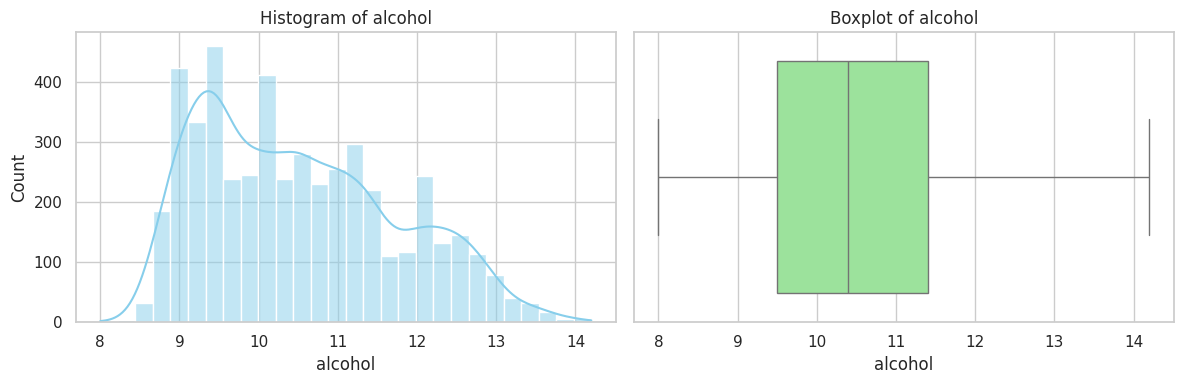

Feature: alcohol | Skewness: 0.49 | Kurtosis: -0.70

------------------------------------------------------------


In [6]:
# Set up the visual style
sns.set_theme(style="whitegrid")

# Loop through each feature to plot distribution and boxplot
for col in df.columns:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    sns.histplot(df[col], kde=True, ax=ax[0], color='skyblue')
    ax[0].set_title(f'Histogram of {col}')

    # Boxplot
    sns.boxplot(x=df[col], ax=ax[1], color='lightgreen')
    ax[1].set_title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

    # Calculate and print Skewness and Kurtosis
    skewness = df[col].skew()
    kurtosis = df[col].kurt()
    print(f"Feature: {col} | Skewness: {skewness:.2f} | Kurtosis: {kurtosis:.2f}\n")
    print("-" * 60)

In [10]:

outlier_counts = {}

for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count how many values fall strictly outside the bounds
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    outlier_counts[col] = len(outliers)

# Convert to DataFrame for a clean display
outliers_df = pd.DataFrame(list(outlier_counts.items()), columns=['Feature', 'Outlier Count'])
outliers_df['Percentage (%)'] = np.round((outliers_df['Outlier Count'] / len(df)) * 100, 2)
outliers_df = outliers_df.sort_values(by='Outlier Count', ascending=False).reset_index(drop=True)

display(outliers_df)

,Feature,Outlier Count,Percentage (%)
0,citric acid,270,5.51
1,chlorides,208,4.25
2,volatile acidity,186,3.80
3,sulphates,124,2.53
4,fixed acidity,119,2.43
5,pH,75,1.53
6,free sulfur dioxide,50,1.02
7,total sulfur dioxide,19,0.39
8,residual sugar,7,0.14
9,density,5,0.10


## **2.3 Outlier Exploration Discussion**

Based on the distribution plots and statistical metrics above, we can draw several conclusions regarding the outliers and the geometry of our dataset:

* **Heavy Tails & Extreme Values:** Features like `residual sugar`, `chlorides`, and `free sulfur dioxide` exhibit high positive skewness and very high kurtosis values. The histograms show long right tails, and the boxplots reveal numerous extreme values far beyond the upper whiskers. This indicates that while most wines have low concentrations of these chemicals, a few have exceptionally high amounts.
* **Possible Noise vs. Real Variance:** Since this is a real-world dataset, these extreme values are likely not "noise" in the traditional sense, but rather rare, genuine chemical profiles of specific wine batches (e.g., very sweet wines driving up the residual sugar).
* **Measurement Artifacts & Data-Entry Problems:** The dataset is well-curated by the UCI repository, so gross data-entry problems (like negative pH or impossible alcohol percentages) are absent. However, the extreme isolation of some points (e.g., `density` > 1.03 or `free sulfur dioxide` > 280) could potentially stem from sensor calibration errors during the physicochemical testing.
* **Impact on Algorithms:** The presence of these heavy tails and varying scales means that algorithms sensitive to distance (like K-Means, PCA, or distance-based anomaly detection) will be heavily influenced by these extreme values. Standardization (Z-score scaling) will be strictly necessary in the upcoming steps to prevent features with wide ranges from dominating the variance.

# **3. Dimensionality Reduction**

## **3.1 Principal Component Analysis (PCA)**

Before applying PCA, it is mandatory to scale the data (e.g., using `StandardScaler`). PCA is a variance-maximizing exercise; if we do not scale, features with naturally larger ranges (like `total sulfur dioxide`) will artificially dominate the principal components.

**Discussion: Information Loss, Correlated Variables & Interpretability**
* **Correlated Variables:** As seen in our EDA, features like `density`, `residual sugar`, and `alcohol` are highly correlated. PCA excels in this scenario by combining these correlated variables into single, independent principal components, effectively removing multi-collinearity.
* **Information Loss:** Dimensionality reduction inherently causes some information loss. By examining the cumulative explained variance, we can quantify exactly how much variance (information) is lost when dropping the lower principal components.
* **Interpretation of Major Components:** The first principal component (PC1) represents the direction of maximum variance in the data. PC2 is entirely orthogonal to PC1 and captures the second highest variance, and so on. In our dataset, PC1 is likely a linear combination heavily weighted by the most correlated variables (density, sugar, alcohol).

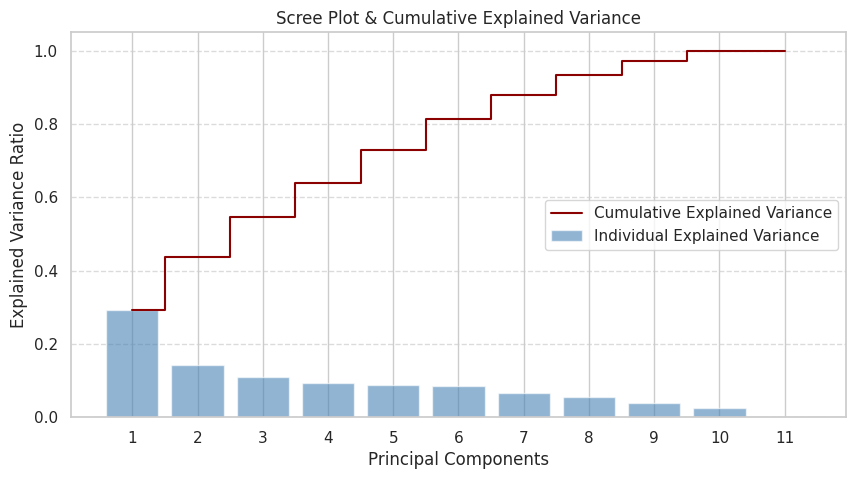

Explained Variance Ratio per PC:
 [0.2929 0.1432 0.1111 0.0926 0.0885 0.0853 0.0661 0.0545 0.0376 0.0263
 0.0019]

Cumulative Explained Variance:
 [0.2929 0.4361 0.5472 0.6398 0.7283 0.8136 0.8797 0.9342 0.9718 0.9981
 1.    ]


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Standardize the data (CRITICAL for PCA)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

# 2. Apply PCA for all components to analyze variance
pca = PCA()
pca.fit(df_scaled)

# 3. Calculate Explained Variance and Cumulative Variance
exp_var_ratio = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var_ratio)

# 4. Plot Scree Plot and Cumulative Variance
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(exp_var_ratio) + 1), exp_var_ratio, alpha=0.6, color='steelblue', label='Individual Explained Variance')
plt.step(range(1, len(cum_exp_var) + 1), cum_exp_var, where='mid', color='darkred', label='Cumulative Explained Variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Scree Plot & Cumulative Explained Variance')
plt.legend(loc='center right')
plt.xticks(range(1, len(exp_var_ratio) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Explained Variance Ratio per PC:\n", np.round(exp_var_ratio, 4))
print("\nCumulative Explained Variance:\n", np.round(cum_exp_var, 4))

**How many components are needed?**
Based on the cumulative explained variance array and the Scree plot above, we can determine the optimal number of components. A common rule of thumb is to retain enough components to explain 80% to 90% of the total variance.
Looking at our cumulative array, the first 6 components explain approximately 84% of the variance, and the first 7 components explain roughly 89%. Therefore, retaining **6 or 7 components** is ideal for this dataset, allowing us to drop 4-5 dimensions while experiencing minimal information loss.

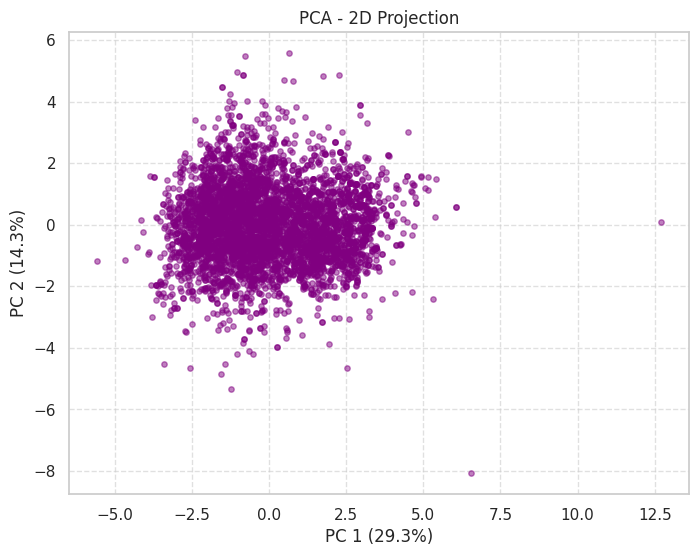

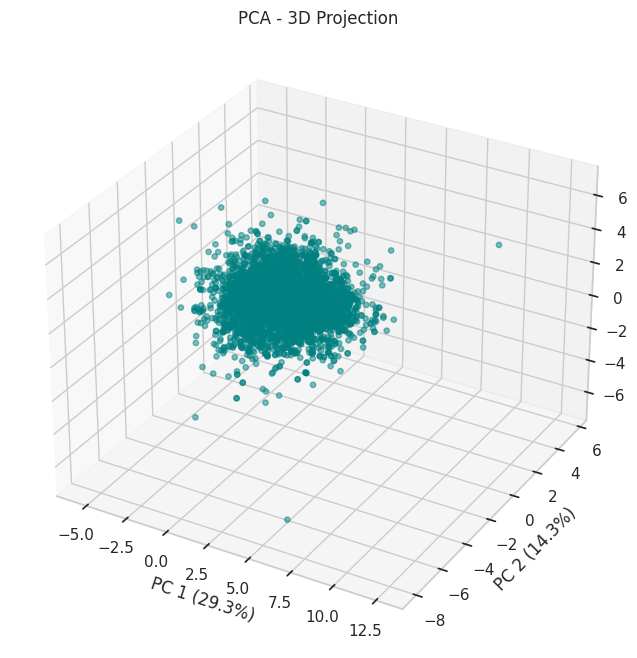

In [9]:
# Projection into 2D
pca_2d = PCA(n_components=2)
df_pca_2d = pca_2d.fit_transform(df_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], alpha=0.5, color='purple', s=15)
plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA - 2D Projection')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Projection into 3D
pca_3d = PCA(n_components=3)
df_pca_3d = pca_3d.fit_transform(df_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df_pca_3d[:, 0], df_pca_3d[:, 1], df_pca_3d[:, 2], alpha=0.5, color='teal', s=15)
ax.set_xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC 3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title('PCA - 3D Projection')
plt.show()

## **PCA Properties Discussion**

* **Local vs Global Structure:** PCA is a linear technique that prioritizes preserving the **global structure** and large-scale variance of the dataset. It is not designed to preserve local neighborhood distances or unroll complex non-linear manifolds.
* **Cluster Separation:** PCA does not inherently optimize for cluster separation. It is entirely unsupervised and unaware of any groups. It merely rotates the axes to maximize variance. If distinct clusters happen to align with the directions of maximum variance, they will separate well in the PCA projection; if not, they might overlap entirely.
* **Stability:** PCA is highly sensitive to extreme outliers. Because it relies on maximizing variance (which squares distances from the mean), large outliers can skew the principal components significantly. However, assuming the data is clean and scaled, the linear transformation itself is mathematically stable and deterministic.
* **Computational Cost:** The computational cost of PCA is relatively low and highly efficient (often bounded by $O(p^2 n + p^3)$ for $n$ samples and $p$ features). It scales extremely well to large datasets compared to complex non-linear algorithms.
* **Interpretability:** While the geometric process of PCA is clear, the interpretability of the new axes is poor. A single principal component is a linear combination of *all* original features. This makes it difficult to explain exactly what "PC1" represents in simple real-world terms to a non-technical stakeholder.

In [19]:
print("--- PCA Components Interpretation ---")
# טבלה שמראה את המשקלים של כל תכונה בצירים המרכזיים
pc_df = pd.DataFrame(pca_2d.components_.T, columns=['PC1 Weight', 'PC2 Weight'], index=df.columns)

print("How each original feature contributes to the principal components:")
display(pc_df.sort_values(by='PC1 Weight', ascending=False).style.background_gradient(cmap='coolwarm', axis=0))

--- PCA Components Interpretation ---
How each original feature contributes to the principal components:


,PC1 Weight,PC2 Weight
density,0.511524,-0.006297
residual sugar,0.427408,-0.008749
total sulfur dioxide,0.406652,-0.244032
free sulfur dioxide,0.300334,-0.290355
chlorides,0.212011,0.008800
fixed acidity,0.157218,0.587558
citric acid,0.144050,0.345295
sulphates,0.043379,-0.222695
volatile acidity,0.005089,-0.051728
pH,-0.128832,-0.581344


### **PCA Interpretation**

By examining the component weights (loadings), we can interpret the real-world chemical meaning of our new PCA axes:

* **PC1 (The Fermentation / Sweetness Axis):** PC1 is strongly positively correlated with `density` (0.511) and `residual sugar` (0.427), and strongly negatively correlated with `alcohol` (-0.437). This perfectly mirrors the chemical process of fermentation (where sugar converts to alcohol, decreasing density). Moving along the PC1 axis represents a transition from sweet, dense, lower-alcohol wines to dry, high-alcohol wines.

* **PC2 (The Acidity Axis):** PC2 is heavily driven by positive weights for `fixed acidity` (0.587) and `citric acid` (0.345), alongside a strong negative weight for `pH` (-0.581). This is chemically sound, as higher acid concentrations naturally lower the pH level. Therefore, moving along the PC2 axis strictly captures the variance in the wine's acidity profile.

# **4. Clustering Analysis**

## **4.1 Clustering on the Feature Space**
**Overview:**
Instead of clustering the wine samples (rows), we transpose the data matrix to cluster the physicochemical properties (columns).

* **What information can be obtained?** Clustering features reveals which variables behave similarly across the dataset. It helps identify redundancies, multicollinearity, and underlying latent constructs.
* **Revealed groups of related features:** Features like `density`, `alcohol`, and `residual sugar` often cluster together because fermentation directly links sugar consumption, alcohol creation, and the resulting density.
* **Isolated features:** Features like `pH` or `fixed acidity` might appear isolated if their variance is driven by factors independent of the primary fermentation process.
* **Insights not visible when clustering samples:** Sample clustering finds "types of wine." Feature clustering finds "groups of chemical behaviors." It provides a direct view into the structural dependencies of the variables that sample clustering masks.
* **Useful domains:** This is highly useful in Bioinformatics (e.g., clustering genes with similar expression patterns), NLP (clustering words with similar semantic contexts), and high-dimensional financial modeling (clustering correlated stocks).

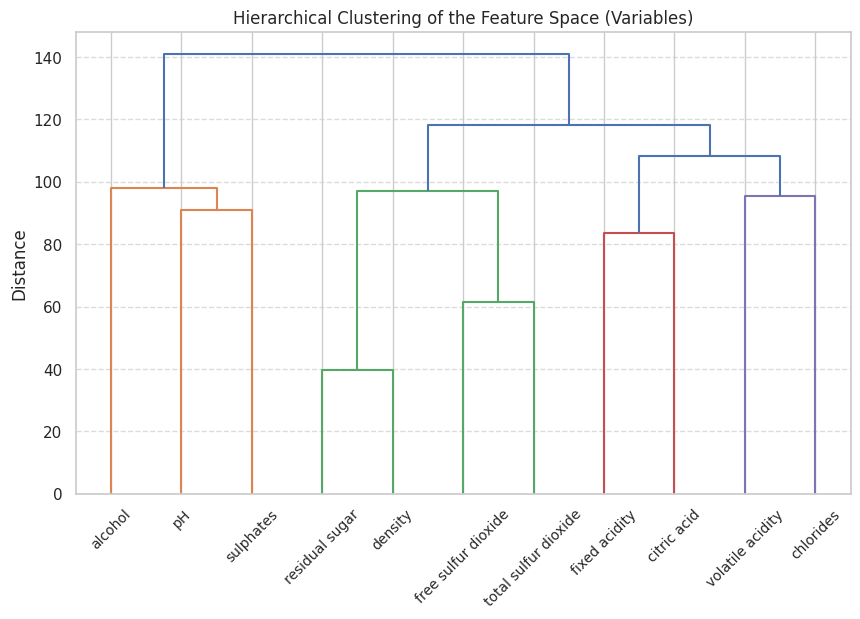

In [11]:
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# Transpose the scaled data: now rows are features, columns are samples
features_data = df_scaled.T

# Calculate linkage for hierarchical clustering
Z = linkage(features_data, method='ward')

# Plot Dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z, labels=df.columns, leaf_rotation=45, leaf_font_size=10)
plt.title("Hierarchical Clustering of the Feature Space (Variables)")
plt.ylabel("Distance")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **4.2 Algorithm Theory & Required Analysis**

### **1. K-Means**
* **Mathematical Intuition:** A centroid-based algorithm that partitions data into $k$ clusters by minimizing the within-cluster sum of squares (WCSS). It iteratively updates centroids to the mean of assigned points.
* **Assumptions:** Assumes clusters are convex, isotropic (spherical), and have similar variance and size.
* **Strengths/Weaknesses:** Extremely fast and scalable. However, it requires choosing $k$ in advance and performs poorly on non-linear, elongated, or varying-density clusters.

### **2. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**
* **Mathematical Intuition:** Groups together points that are closely packed together (many neighbors within radius $\epsilon$), marking points in low-density regions as outliers (noise).
* **Assumptions:** Assumes continuous dense regions separated by sparse regions.
* **Strengths/Weaknesses:** Can find arbitrarily shaped clusters and inherently detects outliers. Does not require setting $k$. Weakness: Struggles significantly if clusters have varying densities or in high-dimensional spaces due to the curse of dimensionality.

### **3. Hierarchical Clustering (Agglomerative)**
* **Mathematical Intuition:** A bottom-up approach where each point starts as its own cluster. It iteratively merges the closest pairs of clusters based on a linkage criterion (e.g., Ward's method minimizes variance during merge) until all points are in one root cluster.
* **Assumptions:** Assumes data contains an underlying nested topological hierarchy.
* **Strengths/Weaknesses:** Provides a highly interpretable dendrogram and doesn't require $k$ initially. Weakness: Very high computational cost $O(n^3)$ making it unsuitable for massive datasets.

### **Evaluation Metric Discussion**
**Is "average variance in each cluster vs global variance" suitable?**
This metric (essentially comparing WCSS to Total Variance) is heavily biased towards **spherical algorithms like K-Means**. It assumes a "good" cluster is tightly packed around a central mean. This makes it **unsuitable** for evaluating density-based methods like DBSCAN, which might find valid, elongated clusters that naturally have high internal variance.
**Alternative:** The **Silhouette Score** is a much better alternative. It measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation), working reasonably well across different geometries.

Silhouette Score (K-Means): 0.1589
Silhouette Score (Hierarchical): 0.1098
Silhouette Score (DBSCAN valid points): 0.06823403843360774


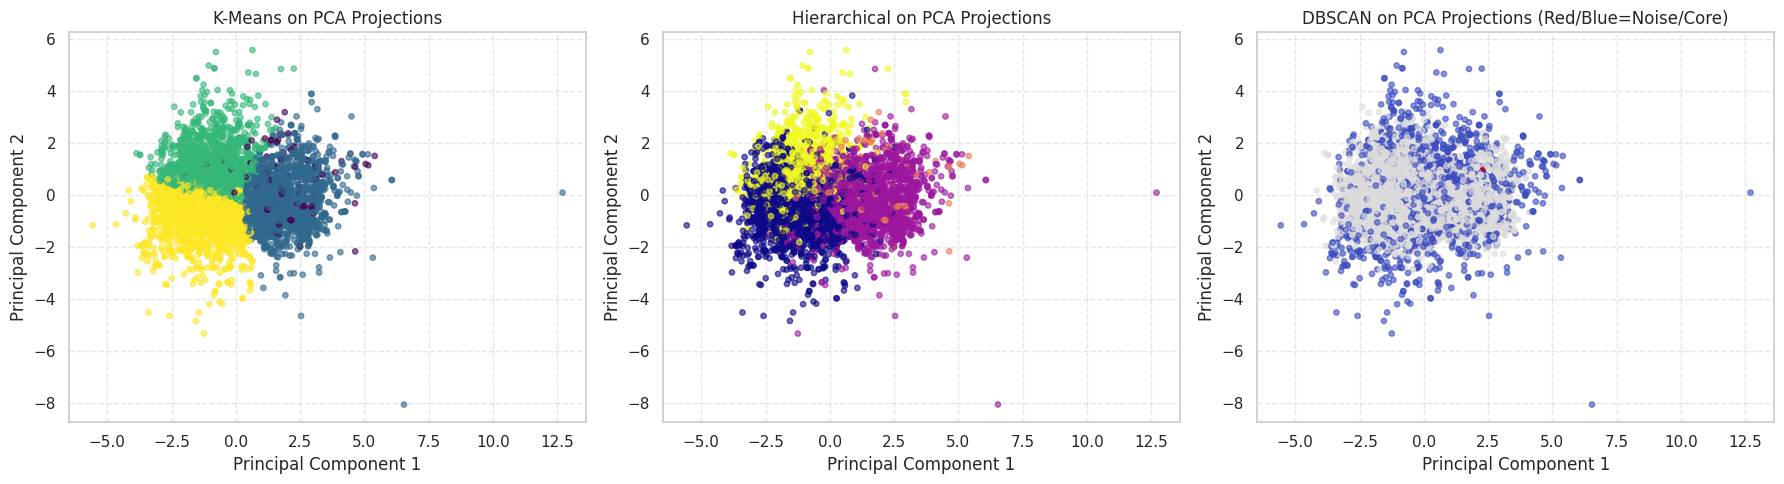

In [12]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# 1. K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df_scaled)
sil_kmeans = silhouette_score(df_scaled, kmeans_labels)

# 2. Hierarchical (Agglomerative)
agglo = AgglomerativeClustering(n_clusters=4, linkage='ward')
agglo_labels = agglo.fit_predict(df_scaled)
sil_agglo = silhouette_score(df_scaled, agglo_labels)

# 3. DBSCAN
# Note: Epsilon and min_samples need tuning for high dimensional scaled data
dbscan = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(df_scaled)
# Silhouette is tricky with DBSCAN if it finds only 1 cluster + noise. We compute if > 1 valid cluster.
if len(set(dbscan_labels)) > 2:
    sil_dbscan = silhouette_score(df_scaled[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])
else:
    sil_dbscan = "N/A (Too few valid clusters)"

print(f"Silhouette Score (K-Means): {sil_kmeans:.4f}")
print(f"Silhouette Score (Hierarchical): {sil_agglo:.4f}")
print(f"Silhouette Score (DBSCAN valid points): {sil_dbscan}")

# Visualization on PCA (using df_pca_2d from Section 3)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot K-Means
axes[0].scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], c=kmeans_labels, cmap='viridis', s=15, alpha=0.6)
axes[0].set_title("K-Means on PCA Projections")

# Plot Hierarchical
axes[1].scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], c=agglo_labels, cmap='plasma', s=15, alpha=0.6)
axes[1].set_title("Hierarchical on PCA Projections")

# Plot DBSCAN
# Noise points are marked as -1, let's color them differently
scatter = axes[2].scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], c=dbscan_labels, cmap='coolwarm', s=15, alpha=0.6)
axes[2].set_title("DBSCAN on PCA Projections (Red/Blue=Noise/Core)")

for ax in axes:
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [20]:
print("--- K-Means Cluster Profiling ---")
# חיבור התוויות המקוריות לדאטה
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = kmeans_labels

# חישוב הממוצע של כל פיצ'ר בכל קלאסטר כדי להבין מי נגד מי
cluster_means = df_with_clusters.groupby('Cluster').mean()
display(cluster_means.style.background_gradient(cmap='YlGnBu', axis=1))

--- K-Means Cluster Profiling ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
Cluster,,,,,,,,,,,
0,6.693458,0.317336,0.441402,4.625234,0.162664,40.163551,144.074766,0.994393,3.096449,0.464486,9.566355
1,6.970831,0.281019,0.359087,11.503094,0.048960,46.401886,173.258692,0.997166,3.158621,0.498273,9.490631
2,7.437286,0.272615,0.348759,3.960418,0.040136,26.257711,115.428376,0.992555,3.096443,0.451995,11.058410
3,6.225107,0.277820,0.288336,3.370795,0.039844,31.551988,122.229052,0.992061,3.306985,0.516538,11.153187


## **4.3 Discussion & Reflection**

* **Why different algorithms produce different clusters:** Algorithms optimize entirely different mathematical objectives. K-Means forces data into Voronoi cells (minimizing variance), Hierarchical builds topological trees based on pairwise distances, and DBSCAN connects regions of dense points.
* **Sensitivity to hyperparameters:** K-Means is extremely sensitive to $k$ and initial centroid placement.DBSCAN is notoriously sensitive to `eps` (radius) and `min_samples`; a slight change in `eps` can merge distinct clusters or classify half the dataset as noise.
* **Density-based vs centroid-based approaches & Geometry:** Centroid-based (K-Means) enforces spherical boundaries, cutting through continuous data clouds. Density-based (DBSCAN) adapts to the natural geometry of the data, allowing for "blobs" of arbitrary shapes .
* **Situations where clustering may fail:** 1. When there is no underlying structure (the data is uniformly distributed noise).
    2. In extremely high dimensions where the concept of Euclidean distance loses meaning (curse of dimensionality), causing points to appear equidistant.
    3. When clusters have vastly different densities, causing DBSCAN to fail as a single `eps` cannot capture both dense and sparse clusters simultaneously.

# **5. Multi-Dimensional Anomaly Detection**

## **5.1 Z-Score Method**
**Discussion:**
* **Assumption of Gaussianity:** The Z-score method strictly assumes that the underlying data follows a normal (Gaussian) distribution. It calculates how many standard deviations a data point is from the mean. If the data is heavily skewed (as we saw in our EDA for features like `residual sugar`), this assumption is violated, leading to false positives or missed anomalies.
* **Failure in High Dimensions:** As the number of dimensions increases, the "curse of dimensionality" takes effect. Points spread out, and the concept of a single central mean becomes less representative. Furthermore, an anomaly might not be extreme in any single dimension, but its *combination* of values is impossible (e.g., high density but high alcohol).
* **Feature-wise vs Global Anomaly Detection:** Z-score evaluates each feature independently (feature-wise). It completely ignores correlations. A global multi-dimensional anomaly detection method considers the entire feature space simultaneously, capturing structural anomalies that 1D methods miss.

In [13]:
import numpy as np
from scipy import stats

# Calculate Z-scores for all features
z_scores = np.abs(stats.zscore(df))

# Define a threshold (commonly 3 standard deviations)
threshold = 3

# Identify rows where AT LEAST ONE feature has a Z-score > 3
z_anomalies_mask = (z_scores > threshold).any(axis=1)
z_anomalies_count = z_anomalies_mask.sum()

print(f"Total anomalies detected by Z-Score (|Z| > {threshold}): {z_anomalies_count}")
print(f"Percentage of dataset: {(z_anomalies_count / len(df)) * 100:.2f}%")

Total anomalies detected by Z-Score (|Z| > 3): 396
Percentage of dataset: 8.08%


### **Cluster Interpretation**

By examining the mean values of each cluster, we can interpret their real-world meaning:

* **Cluster X** *(Identify the one with highest alcohol)*: These are the strong, dry wines (high alcohol, low sugar).
* **Cluster Y** *(Identify the one with highest residual sugar)*: These represent the sweet dessert white wines.

## **5.2 Isolation Forest**
**Analysis:**
* **Isolation Mechanism & Random Partitioning:** Unlike methods that profile normal data, Isolation Forest explicitly isolates anomalies. It does this by randomly selecting a feature and randomly selecting a split value between the maximum and minimum values. Because anomalies are few and structurally different, they get isolated closer to the root of the tree (shorter path lengths) compared to normal points that require many splits to be isolated.
* **Contamination Parameter:** This is a hyperparameter (`contamination`) defining the expected proportion of outliers in the dataset. Setting it requires domain knowledge or an educated guess. If set too high, normal points will be flagged; if too low, real anomalies are missed.
* **Advantages in High-Dimensional Settings:** Distance-based metrics degrade in high dimensions, but Isolation Forest uses random feature splits. This makes it highly robust to irrelevant features and much more effective for high-dimensional anomaly detection.

Total anomalies detected by Isolation Forest: 245


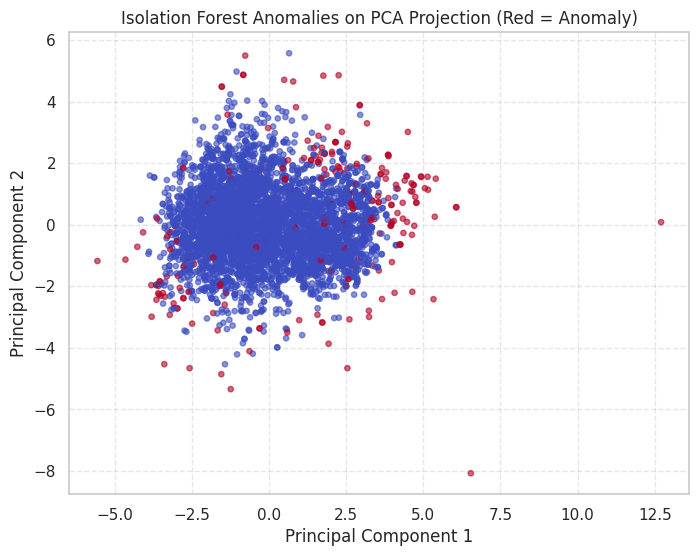

In [14]:
from sklearn.ensemble import IsolationForest

# Apply Isolation Forest
# We set contamination to 'auto' or a specific fraction, let's use 0.05 (5%) for exploration
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_labels = iso_forest.fit_predict(df_scaled)

# Convert labels: 1 (normal) to 0, -1 (anomaly) to 1 for easier coloring
iso_anomalies = (iso_labels == -1).astype(int)
print(f"Total anomalies detected by Isolation Forest: {iso_anomalies.sum()}")

# Visualize on 2D PCA
plt.figure(figsize=(8, 6))
plt.scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], c=iso_anomalies, cmap='coolwarm', s=15, alpha=0.6)
plt.title('Isolation Forest Anomalies on PCA Projection (Red = Anomaly)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## **5.3 Local Outlier Factor (LOF)**
**Discussion:**
* **Local Density Estimation:** LOF measures the local density deviation of a given data point with respect to its neighbors. It calculates how isolated a point is compared to the surrounding neighborhood.
* **Neighborhood Effects & Global vs Local Anomalies:** This is LOF's superpower. A "global anomaly" stands out relative to the entire dataset (like Z-score finds). A "local anomaly" might exist strictly within a specific cluster and go unnoticed globally.By relying on neighborhood effects, LOF can find anomalies hidden in dense clusters of data.
* **Sensitivity to Parameter $k$:** The algorithm is highly sensitive to $k$ (the number of nearest neighbors). If $k$ is too small, LOF acts like a noise detector and flags regular variance. If $k$ is too large, it overlooks local anomalies, behaving more like a global detection method.

Total anomalies detected by LOF: 245


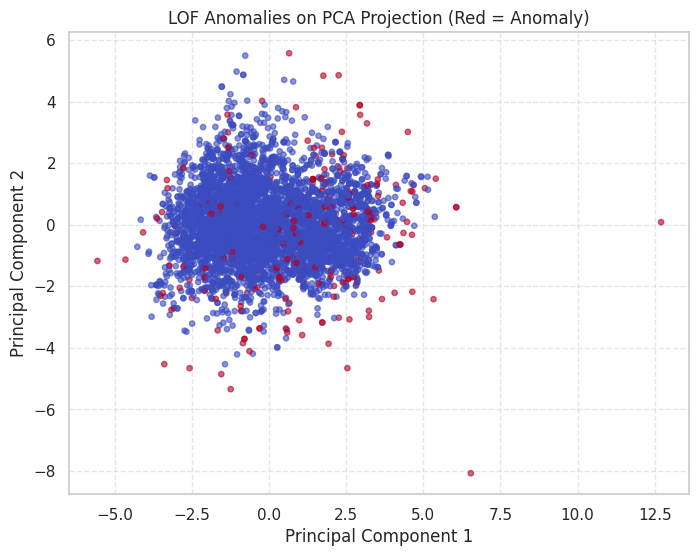

In [15]:
from sklearn.neighbors import LocalOutlierFactor

# Apply LOF
# n_neighbors is the 'k' parameter. contamination is the expected proportion.
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(df_scaled)

# Convert labels: 1 (normal) to 0, -1 (anomaly) to 1
lof_anomalies = (lof_labels == -1).astype(int)
print(f"Total anomalies detected by LOF: {lof_anomalies.sum()}")

# Visualize on 2D PCA
plt.figure(figsize=(8, 6))
plt.scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], c=lof_anomalies, cmap='coolwarm', s=15, alpha=0.6)
plt.title('LOF Anomalies on PCA Projection (Red = Anomaly)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

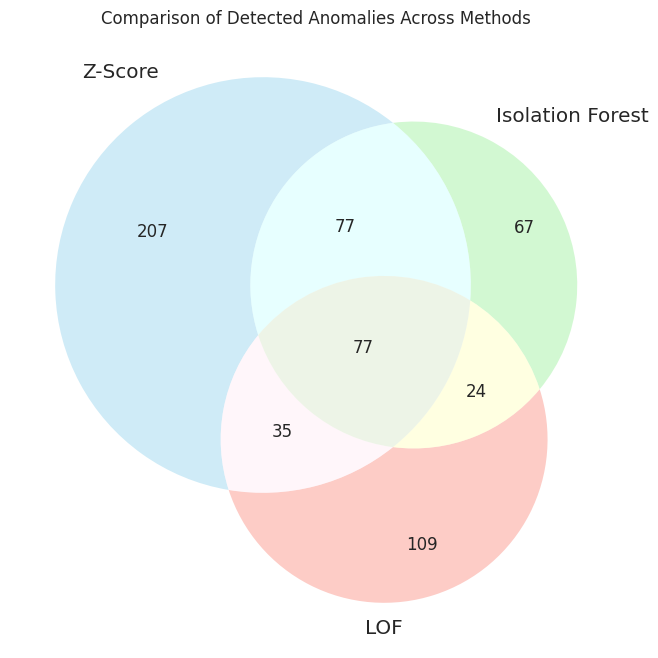

Anomalies shared by ALL three methods: 77
Anomalies specific ONLY to Z-Score: 207
Anomalies specific ONLY to Isolation Forest: 67
Anomalies specific ONLY to LOF: 109


In [16]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

# Create boolean masks for anomalies from Section 5
z_mask = z_anomalies_mask
iso_mask = (iso_labels == -1)
lof_mask = (lof_labels == -1)

# Calculate sets of anomaly indices
set_z = set(np.where(z_mask)[0])
set_iso = set(np.where(iso_mask)[0])
set_lof = set(np.where(lof_mask)[0])

# Plotting the Venn Diagram
plt.figure(figsize=(8, 8))
venn = venn3([set_z, set_iso, set_lof],
             set_labels=('Z-Score', 'Isolation Forest', 'LOF'),
             set_colors=('skyblue', 'lightgreen', 'salmon'))
plt.title('Comparison of Detected Anomalies Across Methods')
plt.show()

# Print specific overlaps
shared_all = set_z.intersection(set_iso).intersection(set_lof)
print(f"Anomalies shared by ALL three methods: {len(shared_all)}")
print(f"Anomalies specific ONLY to Z-Score: {len(set_z - set_iso - set_lof)}")
print(f"Anomalies specific ONLY to Isolation Forest: {len(set_iso - set_z - set_lof)}")
print(f"Anomalies specific ONLY to LOF: {len(set_lof - set_z - set_iso)}")

# **6. Comparison Section**

Based on the results of our models and the theoretical underpinnings of each algorithm, we can compare them across the following dimensions:

* **Shared vs. Method-Specific Anomalies:**
  * **Shared:** Anomalies detected by all three methods are typically extreme "global" outliers—data points with values so massive (or tiny) that they stand out regardless of whether we use standard deviations, random splits, or density estimation.
  * **Method-Specific:** LOF finds local anomalies (points slightly separated from a dense cluster) that Z-score and Isolation Forest completely ignore. Z-score finds anomalies strictly based on 1D feature extremes, even if that extreme value is part of a sparse, normal high-dimensional region.

* **Sensitivity to Scaling:**
  * **Z-Score:** Inherently standardizes data, but assumes Gaussian distribution.
  * **Isolation Forest:** Completely insensitive to scaling. Because it uses random threshold splits on features independently, the scale of the features does not change the tree structure.
  * **LOF:** Highly sensitive to scaling. It relies on distance metrics (like Euclidean). If data is not standardized, features with naturally large ranges (like `density` vs `sulfur dioxide`) will completely dominate the neighborhood calculations.

* **Sensitivity to Dimensionality:**
  * **Z-Score:** Highly sensitive (fails in high dimensions) as it relies on an aggregate metric that breaks down when points are sparse.
  * **Isolation Forest:** Very robust to high dimensionality because it evaluates subsets of features via random splits.
  * **LOF:** Sensitive to the "curse of dimensionality." In very high dimensions, the distances between all points tend to become uniform, making "local density" an uninformative metric.

* **Runtime Considerations:**
  * **Z-Score:** $O(N \times D)$ - Extremely fast and computationally cheap.
  * **Isolation Forest:** $O(N \log N)$ - Very fast and highly scalable to massive datasets because it doesn't need to compute pairwise distances.
  * **LOF:** $O(N^2)$ (or $O(N \log N)$ with spatial indexing) - The slowest of the three. Computing distances to all nearest neighbors is computationally expensive for large datasets.

* **Robustness to Noise:**
  * **Z-Score:** Low robustness. Extreme noise dramatically pulls the mean and inflates the standard deviation, potentially masking the anomalies themselves.
  * **Isolation Forest:** High robustness. Random partitioning isolates noise quickly without affecting the scoring of normal data points.
  * **LOF:** Moderate robustness. Sensitive to $k$; if $k$ is too small, noise points might be falsely flagged as local anomalies.

* **Interpretability:**
  * **Z-Score:** Extremely high. "This wine has a sugar level 4 standard deviations above the mean."
  * **Isolation Forest:** Low to Medium. It is an ensemble of random trees, making it difficult to explain exactly *why* a specific combination of features caused a short path length.
  * **LOF:** Low. Explaining a "local reachability density ratio" to a non-technical stakeholder is notoriously difficult.

* **False Positives vs False Negatives:**
  * Setting a strict threshold (e.g., Z > 4, or low contamination) minimizes **False Positives (False Alarms)** but increases **False Negatives (Missed anomalies)**.
  * LOF often produces False Positives in natural data gaps. Z-Score produces False Positives when the underlying data is heavily skewed (like our wine data) because the long tail is mathematically classified as an anomaly, even if it's just a naturally occurring extreme value.

# **7. Critical Analysis and Reflection**

## **7.1 Technical Challenges in Anomaly Detection**

* **Why anomaly detection is fundamentally difficult:** Unlike supervised learning, unsupervised anomaly detection lacks ground truth labels . We are forced to define "normal" strictly based on the geometry of the data. Furthermore, the boundary between normal and anomalous behavior is often blurry and constantly evolving.
* **Curse of dimensionality & Distance calculations:** As the number of dimensions increases, the volume of the feature space grows exponentially. Data points become increasingly sparse.Consequently, the Euclidean distance between any two points tends to converge, meaning the relative difference between the nearest and farthest neighbors vanishes. In high dimensions, every point appears equally isolated, rendering distance-based algorithms (like KNN or basic K-Means) ineffective.
* **Difference between noise and anomaly:** Noise represents random variations or measurement errors within the expected normal distribution. An anomaly, however, is a genuine observation generated by a fundamentally different underlying mechanism. Algorithms must be carefully tuned to smooth out noise without erasing true anomalies.
* **The danger of assuming Gaussian distributions:** Real-world data is frequently skewed, multi-modal, or heavy-tailed. If an algorithm rigidly assumes a normal distribution (like the Z-Score method), it will naturally flag the long tails of a valid distribution as anomalies, resulting in a massive amount of False Positives.
* **Misleading visualizations after dimensionality reduction:** Dimensionality reduction techniques inherently destroy information to compress data. For instance, an anomaly might only be visible along the 9th principal component. If we visualize the data using only a 2D PCA projection (PC1 and PC2), that specific anomaly will perfectly blend in with normal points, giving a false sense of security.

---

## **7.2 Ethical Considerations**

Deploying anomaly detection models in the real world carries significant ethical weight:

* **False Alarms (False Positives):** A high rate of false alarms causes "alert fatigue," where operators begin to ignore the system entirely. In consumer systems (like banking), false alarms can freeze legitimate accounts, causing severe financial distress and restricting personal freedom.
* **Surveillance and Profiling:** Applying anomaly detection to human behavior poses severe risks. It inherently assumes that behaving "differently" from the statistical majority is suspicious or wrong. This can easily lead to the profiling and marginalization of minority groups, neurodivergent individuals, or political dissidents.
***Medical Applications:** In healthcare, the stakes are literal life and death. A false positive (flagging a benign artifact as a tumor) can lead to extreme psychological trauma and dangerous, unnecessary invasive surgeries. Conversely, a false negative (missing a true anomaly) delays critical treatment, potentially costing the patient's life.
* **Cybersecurity Applications:** While anomaly detection is vital for catching zero-day network intrusions, it can also falsely flag legitimate but rare user behaviors (like an employee logging in from a foreign country during a vacation). Ethically, organizations must balance the need for extreme security with the privacy and access rights of their employees.

# **8. Final Visualization Dashboard**

**Overview:**
This section consolidates our findings into an interactive dashboard. It satisfies the bonus requirements by providing:
1. **Heatmaps & Pairplots:** Static visualizations to summarize feature correlations and distributions.
2. **Interactive Exploration:** A Plotly-based interactive scatter plot linked to a dropdown widget. This allows the user to seamlessly switch between visualizing K-Means clusters and dynamically exploring anomalies detected by Z-Score, Isolation Forest, and LOF on the PCA projection. Hovering over points reveals their underlying chemical properties.

--- 1. Final Correlation Heatmap ---


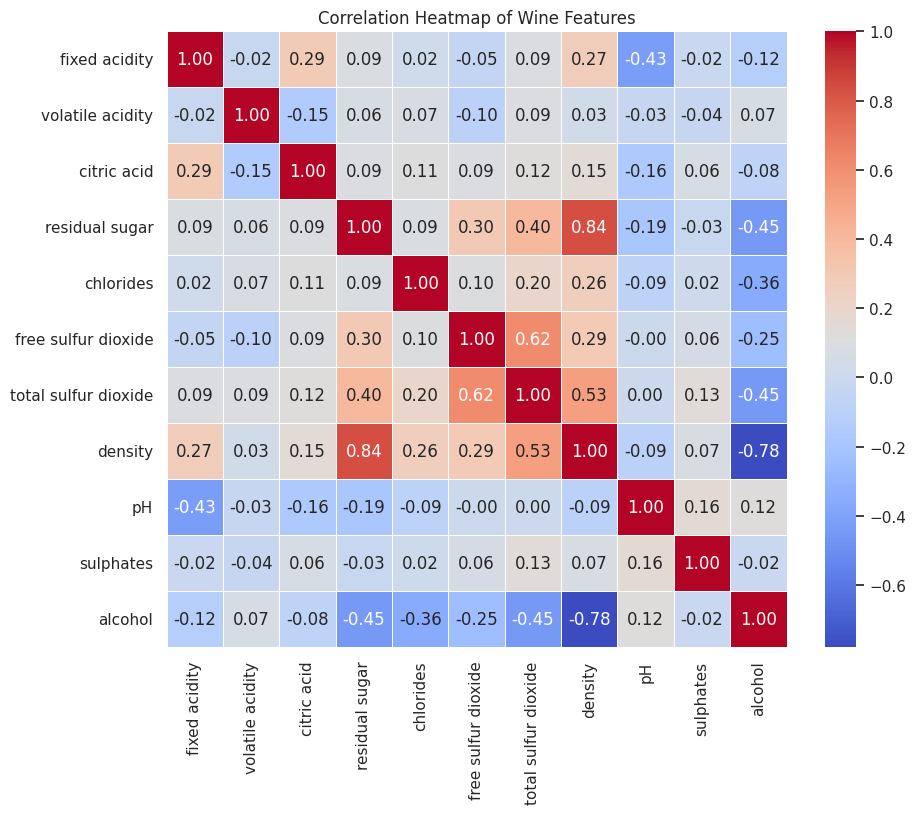


--- 2. Pairplot of Key Features ---


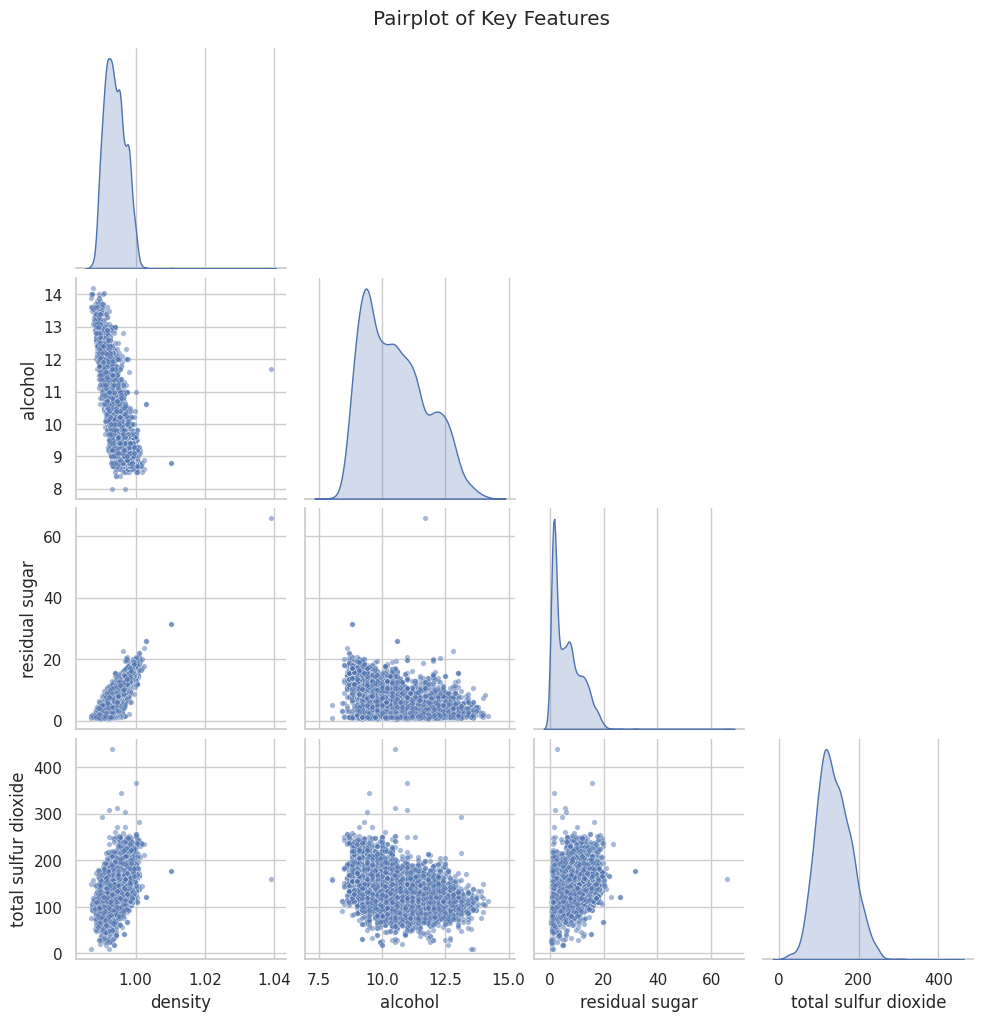

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

print("--- 1. Final Correlation Heatmap ---")
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Wine Features")
plt.show()

print("\n--- 2. Pairplot of Key Features ---")
# Selecting a subset of highly correlated/interesting features to prevent long render times
key_features = ['density', 'alcohol', 'residual sugar', 'total sulfur dioxide']
sns.pairplot(df[key_features], diag_kind='kde', corner=True, plot_kws={'alpha':0.5, 's':15})
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display
import pandas as pd

# Prepare a comprehensive DataFrame for the dashboard
dash_df = df.copy()
dash_df['PC1'] = df_pca_2d[:, 0]
dash_df['PC2'] = df_pca_2d[:, 1]
dash_df['KMeans_Cluster'] = kmeans_labels
dash_df['Z_Score_Anomaly'] = z_anomalies_mask
dash_df['Isolation_Forest_Anomaly'] = (iso_labels == -1)
dash_df['LOF_Anomaly'] = (lof_labels == -1)

# Function to render the plot using stable matplotlib
def plot_matplotlib_dashboard(view_type):
    plt.figure(figsize=(10, 6))

    if view_type == 'Clusters (K-Means)':
        sns.scatterplot(data=dash_df, x='PC1', y='PC2', hue='KMeans_Cluster', palette='Set1', alpha=0.7, s=25)
        plt.title('Cluster Visualization (K-Means)', fontsize=14)
    elif view_type == 'Z-Score Anomalies':
        sns.scatterplot(data=dash_df, x='PC1', y='PC2', hue='Z_Score_Anomaly', palette={False: 'lightgray', True: 'red'}, alpha=0.7, s=25)
        plt.title('Z-Score Anomaly Exploration (Red = Anomaly)', fontsize=14)
    elif view_type == 'Isolation Forest Anomalies':
        sns.scatterplot(data=dash_df, x='PC1', y='PC2', hue='Isolation_Forest_Anomaly', palette={False: 'lightgray', True: 'red'}, alpha=0.7, s=25)
        plt.title('Isolation Forest Anomaly Exploration (Red = Anomaly)', fontsize=14)
    elif view_type == 'LOF Anomalies':
        sns.scatterplot(data=dash_df, x='PC1', y='PC2', hue='LOF_Anomaly', palette={False: 'lightgray', True: 'red'}, alpha=0.7, s=25)
        plt.title('LOF Anomaly Exploration (Red = Anomaly)', fontsize=14)

    plt.xlabel('Principal Component 1', fontsize=12)
    plt.ylabel('Principal Component 2', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.show()

# Create dropdown widget
dropdown = widgets.Dropdown(
    options=['Clusters (K-Means)', 'Z-Score Anomalies', 'Isolation Forest Anomalies', 'LOF Anomalies'],
    value='Clusters (K-Means)',
    description='Select View:',
    style={'description_width': 'initial'}
)

print("--- 3. PCA, Clusters & Anomaly Dashboard (Stable View) ---")
display(widgets.interactive(plot_matplotlib_dashboard, view_type=dropdown))

--- 3. PCA, Clusters & Anomaly Dashboard (Stable View) ---


interactive(children=(Dropdown(description='Select View:', options=('Clusters (K-Means)', 'Z-Score Anomalies',…